In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
a = 1.0 * 10**(-9)
a_nm = a * 10**9
N = 49
L = (N + 1) * a
L_nm = (N+1)*a_nm
print("N = ", N)
print("L = ",L,"m")
print("L_nm = ",L_nm,"nm")
print("a_nm = ",a_nm,"nm")

N =  49
L =  5.0000000000000004e-08 m
L_nm =  50.0 nm
a_nm =  1.0 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [4]:
t = (h_bar**2) / (2 * m_el * a**2)
t = t / eV_unit
print("t = ",t)

t =  0.03809981988649954


In [5]:
sys = kwant.Builder()
lat = kwant.lattice.chain(a_nm)

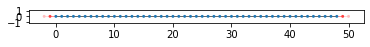

In [6]:
def onsite(site, x0, w0, U0):
    (x,) = site.pos
    if (abs(x - x0) <= w0/2):
        return 2 * t + U0
    else:
        return 2 * t

for i in range(N):
    sys[lat(i)] = onsite
    
sys[lat.neighbors()] = -t

leadl = kwant.Builder(kwant.TranslationalSymmetry((-a_nm,)))
leadl[lat(0)] = 2*t
leadl[lat.neighbors()] = -t

leadr = leadl.reversed()

sys.attach_lead(leadl)
sys.attach_lead(leadr)
                       
kwant.plot(sys);

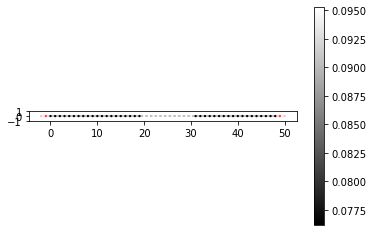

In [20]:
sysf = sys.finalized()
U0p = 0.5 * t 
# p - prime
x0p = 25
w0p = 10

kwant.plot(sysf, site_color = lambda site: sysf.hamiltonian(site, site, params = dict(U0=U0p, x0=x0p, w0=w0p)));

#dict - dictionry - means look for (U0,x0,w0) and give them values (p)
#params - paramiters

#the brighter it is the bigger onsite energy

In [25]:
def calc_T(sysf, E, U0, x0, w0):
    smatrix = kwant.smatrix(sysf, E, params=dict(U0=U0, x0=x0, w0=w0))
    return smatrix.transmission(1, 0)

U0p = blue  0.01904990994324977
U0p = orange  0.02
U0pp =   0.02


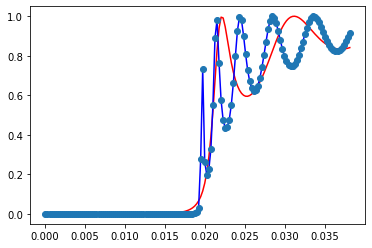

In [44]:
Emin = 0.0001
Emax = 2 * U0p
NE = 150

Etab = np.linspace(Emin, Emax, NE)
Ttab_1 = np.zeros(NE)
Ttab_2 = np.zeros(NE)
U01 = 0.02

U0pp = 0.5 * t 
x0pp = 25
w0pp = 6
Etab = np.linspace(Emin, Emax, NE)
Ttab_p = np.zeros(NE)

for i in range(NE):
    Ttab_1[i] = calc_T(sysf, Etab[i], U0p, x0p, w0p)
    Ttab_2[i] = calc_T(sysf, Etab[i], U0p, x0p, x0p)
    Ttab_p[i] = calc_T(sysf, Etab[i], U0pp, x0pp, x0pp)
    
print("U0p = blue ", U0p)
print("U0p = orange ", U01)
print("U0pp =  ", U01)
plt.plot(Etab, Ttab_1, "r");
#plt.ylim(0, 0.2)

plt.plot(Etab, Ttab_2, "b");
#plt.ylim();

plt.plot(Etab, Ttab_p, "o");